In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.cluster import KMeans
 
from sklearn.preprocessing import StandardScaler
 
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("../f1_clean.csv")
 
FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
 
df = df.dropna(subset=FEATURES).reset_index(drop=True)
 
X = df[FEATURES].values
 
print(f"Dataset loaded: {X.shape}")  # (5302, 4)

Dataset loaded: (5302, 4)


In [3]:
 
scaler = StandardScaler()
 
X_scaled = scaler.fit_transform(X)
 
print("Before scaling — first row:", X[0])
print("After scaling  — first row:", X_scaled[0].round(3))

Before scaling — first row: [  3.     49.     25.    191.706]
After scaling  — first row: [-1.25  -1.188  2.57  -0.644]


In [4]:
inertias = []
silhouettes = []
K_range = range(2, 11)
 
for k in K_range:
    km = KMeans(n_clusters=k, init='random', n_init=10,
                random_state=42, max_iter=300)
 
    km.fit(X_scaled)
 
    inertias.append(km.inertia_)
 
    labels = km.labels_   # cluster assignment for every row
    silhouettes.append(silhouette_score(X_scaled, labels))
 
    print(f"K={k:2d} | Inertia: {km.inertia_:8.1f} | Silhouette: {silhouettes[-1]:.3f}")

K= 2 | Inertia:  14537.8 | Silhouette: 0.311
K= 3 | Inertia:  11116.9 | Silhouette: 0.289
K= 4 | Inertia:   9689.3 | Silhouette: 0.271
K= 5 | Inertia:   8510.9 | Silhouette: 0.254
K= 6 | Inertia:   7579.3 | Silhouette: 0.264
K= 7 | Inertia:   6690.4 | Silhouette: 0.271
K= 8 | Inertia:   6154.6 | Silhouette: 0.268
K= 9 | Inertia:   5689.0 | Silhouette: 0.268
K=10 | Inertia:   5327.7 | Silhouette: 0.271


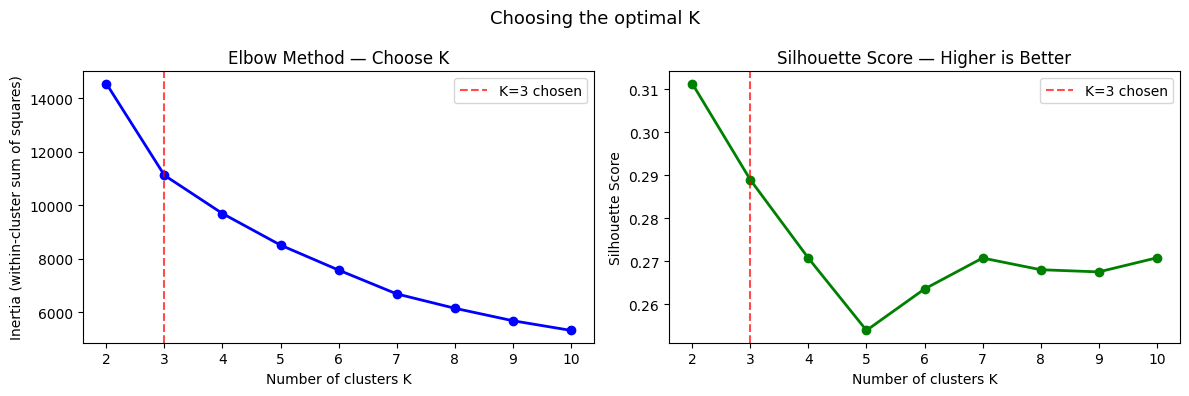

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel("Number of clusters K")
ax1.set_ylabel("Inertia (within-cluster sum of squares)")
ax1.set_title("Elbow Method — Choose K")
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 chosen')
ax1.legend()
 
ax2.plot(K_range, silhouettes, 'go-', linewidth=2, markersize=6)
ax2.set_xlabel("Number of clusters K")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score — Higher is Better")
ax2.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 chosen')
ax2.legend()
 
plt.suptitle("Choosing the optimal K", fontsize=13)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
K = 3
 
km_final = KMeans(
    n_clusters=K,
    init='random',
    n_init=10,
    random_state=42,
    max_iter=300
)
 
km_final.fit(X_scaled)
 
df['cluster'] = km_final.labels_
 
print(f"\nFinal K-Means (K={K})")
print(f"Inertia: {km_final.inertia_:.1f}")
print(f"Silhouette score: {silhouette_score(X_scaled, km_final.labels_):.3f}")
print(f"\nCluster sizes:\n{df['cluster'].value_counts().sort_index()}")


Final K-Means (K=3)
Inertia: 11116.9
Silhouette score: 0.289

Cluster sizes:
cluster
0    2209
1    1571
2    1522
Name: count, dtype: int64



=== Cluster Profiles (mean values) ===
          grid   laps  points  fastestLapSpeed  podium
cluster                                               
0        13.83  53.07    1.56           211.32    0.00
1        12.90  68.60    2.40           191.05    0.02
2         3.96  59.04   15.47           209.96    0.57


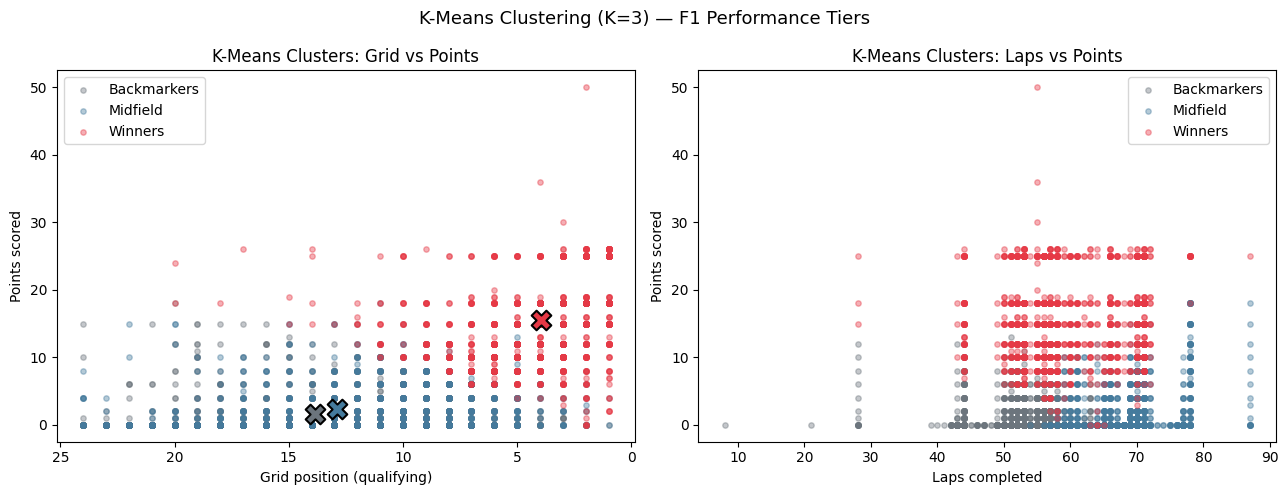

In [7]:
print("\n=== Cluster Profiles (mean values) ===")
profile = df.groupby('cluster')[FEATURES + ['podium']].mean().round(2)
print(profile)

cluster_labels = {
    df.groupby('cluster')['points'].mean().idxmax(): 'Winners',
    df.groupby('cluster')['points'].mean().idxmin(): 'Backmarkers',
}

for c in [0, 1, 2]:
    if c not in cluster_labels:
        cluster_labels[c] = 'Midfield'
 
df['cluster_name'] = df['cluster'].map(cluster_labels)
 
colors = {'Winners': '#e63946', 'Midfield': '#457b9d', 'Backmarkers': '#6c757d'}
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 

ax = axes[0]
for name, group in df.groupby('cluster_name'):
    ax.scatter(group['grid'], group['points'],
               label=name, color=colors[name],
               alpha=0.4, s=15)
 

centroids_original = scaler.inverse_transform(km_final.cluster_centers_)

for i, (cx, cy) in enumerate(zip(centroids_original[:, 0], centroids_original[:, 2])):
    name = cluster_labels[i]
    ax.scatter(cx, cy, color=colors[name], s=200, marker='X',
               edgecolors='black', linewidths=1.5, zorder=5)
 
ax.set_xlabel("Grid position (qualifying)")
ax.set_ylabel("Points scored")
ax.set_title("K-Means Clusters: Grid vs Points")
ax.legend()
ax.invert_xaxis()
 

ax2 = axes[1]
for name, group in df.groupby('cluster_name'):
    ax2.scatter(group['laps'], group['points'],
                label=name, color=colors[name],
                alpha=0.4, s=15)
ax2.set_xlabel("Laps completed")
ax2.set_ylabel("Points scored")
ax2.set_title("K-Means Clusters: Laps vs Points")
ax2.legend()
 
plt.suptitle("K-Means Clustering (K=3) — F1 Performance Tiers", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("\n=== Cluster Summary ===")
for c in sorted(df['cluster'].unique()):
    name = cluster_labels[c]
    subset = df[df['cluster'] == c]
    print(f"\n[{name}] — {len(subset)} drivers")
    print(f"  Avg grid position : {subset['grid'].mean():.1f}")
    print(f"  Avg points        : {subset['points'].mean():.1f}")
    print(f"  Avg laps completed: {subset['laps'].mean():.1f}")
    print(f"  Podium rate       : {subset['podium'].mean()*100:.1f}%")



=== Cluster Summary ===

[Backmarkers] — 2209 drivers
  Avg grid position : 13.8
  Avg points        : 1.6
  Avg laps completed: 53.1
  Podium rate       : 0.4%

[Midfield] — 1571 drivers
  Avg grid position : 12.9
  Avg points        : 2.4
  Avg laps completed: 68.6
  Podium rate       : 2.1%

[Winners] — 1522 drivers
  Avg grid position : 4.0
  Avg points        : 15.5
  Avg laps completed: 59.0
  Podium rate       : 57.0%
